this file is to run all the experiments for benchmarks

to run vit, cnn, resnet, gopro clip, dinov2

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shutil
import torch.nn as nn
import os
import pandas as pd
import random

from PatchDataset import load_dataset
from torch.utils.data import DataLoader,Subset,Dataset
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
from transformers import CLIPProcessor, CLIPModel

from PatchDataset import load_dataset,load_augmented_dataset
from pipeline import set_seed,predict_probs, eval_clip,compute_binary_metrics
from pipeline import fit_binary_classifier, evaluate, set_seed,predict_probs
from torch.optim.lr_scheduler import StepLR
from torch.optim import Adam
from torchvision.models import resnet18,ResNet18_Weights


In [3]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

PATCHES_ROOT = "patches_dataset/patches_v3_seed42_pad1.6_iouth0.09"
traincsv_path = os.path.join(PATCHES_ROOT, "metadata.csv")
testcsv_path = "patches_dataset/test_patches_v3/test_metadata.csv"

# loading the dataset
traindf = pd.read_csv(traincsv_path)
traindf["patch_id"] = traindf["patch_id"].astype(int)
traindf["label"] = traindf["label"].astype(int)
traindf["type"] = traindf["type"].astype(str)

testdf = pd.read_csv(testcsv_path)
testdf["patch_id"] = testdf["patch_id"].astype(int)
testdf["label"] = testdf["label"].astype(int)
testdf["type"] = testdf["type"].astype(str)

train_dataset,val_dataset,train_loader,val_loader,test_dataset,test_loader = load_dataset(traindf,testdf,PATCHES_ROOT,BATCH_SIZE)

for xb,yb in train_loader:
    print(xb.shape,yb.shape,min(yb),max(yb))
    break

AUG_ROOT = "patches_dataset/patches_v4_train_aug"
PATH_AUG_METADATA = os.path.join(AUG_ROOT, "metadata.csv")

aug_train_dataset,aug_val_dataset,aug_train_loader,aug_val_loader,aug_test_dataset,aug_test_loader = load_augmented_dataset(
    PATCHES_ROOT,
    AUG_ROOT,
    PATH_AUG_METADATA,
    testcsv_path,
    BATCH_SIZE
)

for xb, yb in aug_train_loader:
    print(xb.shape, yb.shape, min(yb), max(yb))
    break


cuda
train/val: 15858 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)
train_aug/test: 31716 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


# Gopro CLIP

In [4]:
## version 2 

# how it works: learn the 512 dim vectors 

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

class GOProPromptLearner(nn.Module):
    def __init__(self, num_classes=2, ctx_len=4):
        super().__init__()
        self.num_classes = num_classes
        self.ctx_len = ctx_len         
        dim = 512

        self.ctx = nn.Parameter(torch.randn(ctx_len, dim) * 0.02)
        self.class_token = nn.Parameter(torch.randn(num_classes, dim) * 0.02)
        self.temp = nn.Parameter(torch.ones([]) * 0.07)

    def forward(self, batch_size):
        # Returns ONLY the class tokens, fused with ctx mean
        # Shape: (B, num_classes, 512)
        ctx_mean = self.ctx.mean(0, keepdim=True)  # (1, 512)
        class_toks = self.class_token  # (2, 512)
        fused = class_toks + ctx_mean  # (2, 512) broadcast
        fused = fused.unsqueeze(0).expand(batch_size, -1, -1) # (B, 2, 512)
        return F.normalize(fused, dim=-1)


def train_gopro_prompts(clip_model, train_loader, num_epochs=10, lr=1e-3, ctx_len=4):
    device = next(clip_model.parameters()).device
    prompt_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)

    for p in clip_model.parameters():
        p.requires_grad_(False)

    optimizer = torch.optim.AdamW(prompt_learner.parameters(), lr=lr)
    prompt_learner.train()

    for epoch in range(num_epochs):
        total_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device).long()

            with torch.no_grad():
                vision_outputs = clip_model.vision_model(pixel_values=images)
                pooled    = vision_outputs.pooler_output
                img_feats = clip_model.visual_projection(pooled)
                img_feats = F.normalize(img_feats, dim=-1)   # (B, 512)

            text_feats = prompt_learner(images.size(0))       # (B, 2, 512)

            # Logits over both classes — consistent binary CE
            logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp()               # (B, 2)

            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(prompt_learner.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    return prompt_learner


def eval_gopro_prompts(clip_model, prompt_learner, test_loader, device):
    clip_model.eval()
    prompt_learner.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)

            vision_outputs = clip_model.vision_model(pixel_values=images)
            pooled    = vision_outputs.pooler_output
            img_feats = clip_model.visual_projection(pooled)
            img_feats = F.normalize(img_feats, dim=-1)

            text_feats = prompt_learner(images.size(0))        # (B, 2, 512)

            # Same logits as training — take softmax prob of class 1 (tree)
            logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp()                # (B, 2)
            probs  = torch.softmax(logits, dim=-1)[:, 1]       # P(tree)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

## normal dataset

In [ ]:
#from gopro_prompts import train_gopro_prompts,eval_gopro_prompts
print(device)
num_epochs = 10
ctx_len = 8
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
gopro_learner = train_gopro_prompts(model_clip, train_loader, num_epochs=num_epochs, ctx_len=ctx_len)

In [ ]:
# saving 
torch.save(gopro_learner.state_dict(), f"models/gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth")

In [ ]:
# loading 
gopro_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)
gopro_learner.load_state_dict(torch.load(f"models/gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth", map_location=device))
gopro_learner.eval()

In [ ]:
probs_gopro, labels = eval_gopro_prompts(model_clip, gopro_learner, test_loader, device)
metrics_gopro = compute_binary_metrics(labels, probs_gopro)
print(metrics_gopro)

In [ ]:
# === Now use scores_gopro in your existing ROC/PR code ===
fpr, tpr, _ = roc_curve(labels, probs_gopro)
roc_auc_gopro = auc(fpr, tpr)
print(f"GOPro ROC AUC: {roc_auc_gopro:.4f}")

prec, rec, _ = precision_recall_curve(labels, probs_gopro)
ap_gopro = average_precision_score(labels, probs_gopro)
print(f"GOPro AP: {ap_gopro:.4f}")


In [ ]:
preds_gopro = (probs_gopro >= 0.5).astype(int)
print(classification_report(labels, preds_gopro, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.84      0.72      0.77      1249
    Positive       0.88      0.94      0.91      2716

    accuracy                           0.87      3965
   macro avg       0.86      0.83      0.84      3965
weighted avg       0.87      0.87      0.87      3965



In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_gopro:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap_gopro:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


## augmented dataset

In [5]:
#from gopro_prompts import train_gopro_prompts,eval_gopro_prompts
print(device)
num_epochs = 10
ctx_len = 8
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
aug_gopro_learner = train_gopro_prompts(model_clip, aug_train_loader, num_epochs=num_epochs, ctx_len=ctx_len)

cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 19212.91it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 992/992 [03:23<00:00,  4.87it/s]


Epoch 1, Loss: 0.6216


Epoch 2: 100%|██████████| 992/992 [03:12<00:00,  5.14it/s]


Epoch 2, Loss: 0.5668


...

Epoch 8, Loss: 0.3254


Epoch 9: 100%|██████████| 992/992 [03:04<00:00,  5.38it/s]


Epoch 9, Loss: 0.3185


Epoch 10: 100%|██████████| 992/992 [03:03<00:00,  5.41it/s]

Epoch 10, Loss: 0.3128


In [6]:
# saving 
torch.save(aug_gopro_learner.state_dict(), f"models/aug_gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth")

In [7]:
# loading 
aug_gopro_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)
aug_gopro_learner.load_state_dict(torch.load(f"models/aug_gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth", map_location=device))
aug_gopro_learner.eval()

GOProPromptLearner()

In [8]:
aug_probs_gopro, labels = eval_gopro_prompts(model_clip, aug_gopro_learner, aug_test_loader, device)
aug_metrics_gopro = compute_binary_metrics(labels, aug_probs_gopro)
print(aug_metrics_gopro)

Evaluating: 100%|██████████| 124/124 [00:24<00:00,  5.06it/s]


{'accuracy': 0.8723833543505675, 'balanced_accuracy': 0.8687925303423888, 'precision': 0.9313036690085871, 'recall': 0.8784977908689249, 'f1': 0.9041303524062144, 'auroc': 0.9447961904133028, 'ap': 0.9706227368866467, 'tn': 1073, 'fp': 176, 'fn': 330, 'tp': 2386, 'n': 3965}


In [9]:
# === Now use scores_gopro in your existing ROC/PR code ===
fpr, tpr, _ = roc_curve(labels, aug_probs_gopro)
roc_auc_gopro = auc(fpr, tpr)
print(f"GOPro ROC AUC: {roc_auc_gopro:.4f}")

prec, rec, _ = precision_recall_curve(labels, aug_probs_gopro)
ap_gopro = average_precision_score(labels, aug_probs_gopro)
print(f"GOPro AP: {ap_gopro:.4f}")


GOPro ROC AUC: 0.9448
GOPro AP: 0.9706


In [10]:
preds_gopro = (aug_probs_gopro >= 0.5).astype(int)
print(classification_report(labels, preds_gopro, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.76      0.86      0.81      1249
    Positive       0.93      0.88      0.90      2716

    accuracy                           0.87      3965
   macro avg       0.85      0.87      0.86      3965
weighted avg       0.88      0.87      0.87      3965



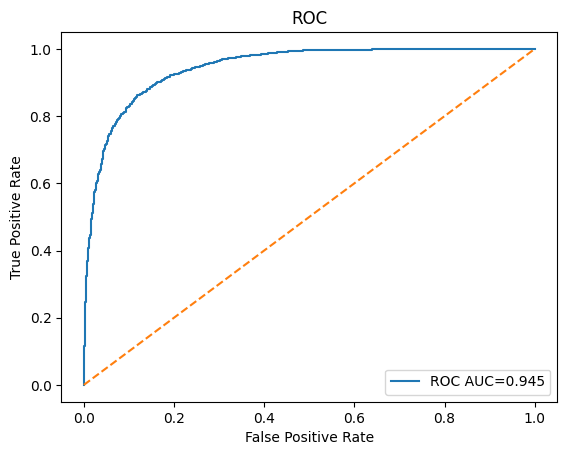

In [11]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_gopro:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

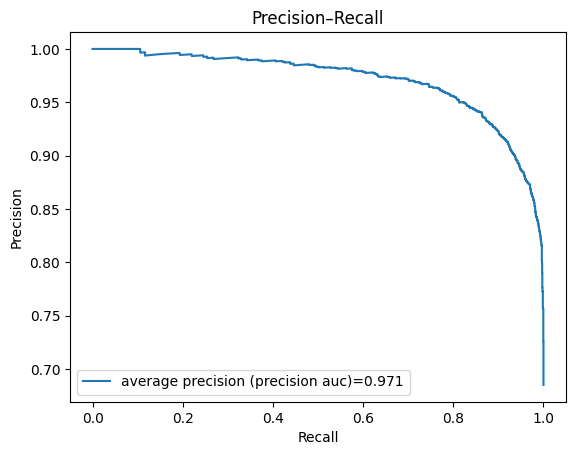

In [12]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap_gopro:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


# VIT

In [13]:
class PatchEmbedding(nn.Module):
  def __init__(self, d_model, img_size, patch_size, n_channels):
    super().__init__()

    self.d_model = d_model # Dimensionality of Model
    self.img_size = img_size # Image Size
    self.patch_size = patch_size # Patch Size
    self.n_channels = n_channels # Number of Channels

    self.linear_project = nn.Conv2d(self.n_channels, self.d_model, kernel_size=self.patch_size, stride=self.patch_size)

  # B: Batch Size
  # C: Image Channels
  # H: Image Height
  # W: Image Width
  # P_col: Patch Column
  # P_row: Patch Row
  def forward(self, x):
    x = self.linear_project(x) # (B, C, H, W) -> (B, d_model, P_col, P_row)

    x = x.flatten(2) # (B, d_model, P_col, P_row) -> (B, d_model, P)

    x = x.transpose(-2, -1) # (B, d_model, P) -> (B, P, d_model)

    return x
  
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_seq_length):
    super().__init__()

    self.cls_token = nn.Parameter(torch.randn(1, 1, d_model)) # Classification Token

    # Creating positional encoding
    pe = torch.zeros(max_seq_length, d_model)

    for pos in range(max_seq_length):
      for i in range(d_model):
        if i % 2 == 0:
          pe[pos][i] = np.sin(pos/(10000 ** (i/d_model)))
        else:
          pe[pos][i] = np.cos(pos/(10000 ** ((i-1)/d_model)))

    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    # Expand to have class token for every image in batch
    tokens_batch = self.cls_token.expand(x.size()[0], -1, -1)

    # Adding class tokens to the beginning of each embedding
    x = torch.cat((tokens_batch,x), dim=1)

    # Add positional encoding to embeddings
    x = x + self.pe

    return x

class AttentionHead(nn.Module):
  def __init__(self, d_model, head_size):
    super().__init__()
    self.head_size = head_size

    self.query = nn.Linear(d_model, head_size)
    self.key = nn.Linear(d_model, head_size)
    self.value = nn.Linear(d_model, head_size)

  def forward(self, x):
    # Obtaining Queries, Keys, and Values
    Q = self.query(x)
    K = self.key(x)
    V = self.value(x)

    # Dot Product of Queries and Keys
    attention = Q @ K.transpose(-2,-1)

    # Scaling
    attention = attention / (self.head_size ** 0.5)

    attention = torch.softmax(attention, dim=-1)

    attention = attention @ V

    return attention
  
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, n_heads):
    super().__init__()
    self.head_size = d_model // n_heads

    self.W_o = nn.Linear(d_model, d_model)

    self.heads = nn.ModuleList([AttentionHead(d_model, self.head_size) for _ in range(n_heads)])

  def forward(self, x):
    # Combine attention heads
    out = torch.cat([head(x) for head in self.heads], dim=-1)

    out = self.W_o(out)

    return out
  
class TransformerEncoder(nn.Module):
  def __init__(self, d_model, n_heads, r_mlp=4):
    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads

    # Sub-Layer 1 Normalization
    self.ln1 = nn.LayerNorm(d_model)

    # Multi-Head Attention
    self.mha = MultiHeadAttention(d_model, n_heads)

    # Sub-Layer 2 Normalization
    self.ln2 = nn.LayerNorm(d_model)

    # Multilayer Perception
    self.mlp = nn.Sequential(
        nn.Linear(d_model, d_model*r_mlp),
        nn.GELU(),
        nn.Linear(d_model*r_mlp, d_model)
    )

  def forward(self, x):
    # Residual Connection After Sub-Layer 1
    out = x + self.mha(self.ln1(x))

    # Residual Connection After Sub-Layer 2
    out = out + self.mlp(self.ln2(out))

    return out
  
class VisionTransformer(nn.Module):
  def __init__(self, d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers):
    super().__init__()

    assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0, "img_size dimensions must be divisible by patch_size dimensions"
    assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

    self.d_model = d_model # Dimensionality of model
    self.n_classes = n_classes # Number of classes
    self.img_size = img_size # Image size
    self.patch_size = patch_size # Patch size
    self.n_channels = n_channels # Number of channels
    self.n_heads = n_heads # Number of attention heads

    self.n_patches = (self.img_size[0] * self.img_size[1]) // (self.patch_size[0] * self.patch_size[1])
    self.max_seq_length = self.n_patches + 1

    self.patch_embedding = PatchEmbedding(self.d_model, self.img_size, self.patch_size, self.n_channels)
    self.positional_encoding = PositionalEncoding( self.d_model, self.max_seq_length)
    self.transformer_encoder = nn.Sequential(*[TransformerEncoder( self.d_model, self.n_heads) for _ in range(n_layers)])

    # Classification MLP
    #self.classifier = nn.Sequential(
    #    nn.Linear(self.d_model, self.n_classes),
    #    nn.Softmax(dim=-1)
    #)
    self.classifier = nn.Linear(self.d_model, self.n_classes)

  def forward(self, images):
    x = self.patch_embedding(images)

    x = self.positional_encoding(x)

    x = self.transformer_encoder(x)

    x = self.classifier(x[:,0]) #logits 

    return x

In [14]:
d_model = 384
n_classes = 2
img_size = (224,224)
patch_size = (16,16)
n_channels = 3
n_heads = 6
n_layers = 6
batch_size = 32
epochs = 20
lr = 2e-5

In [15]:
print(device)
transformer = VisionTransformer(d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers).to(device)

cuda


## augmented dataset

In [17]:
# aug dataset

criterion = nn.CrossEntropyLoss()
optimizer = Adam(transformer.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
EPOCHS = 20
early_stopping = 3

config = {
    "model": "vit",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": 2e-5,
    "early_stopping_patience": early_stopping,
}

run_dir = "runs/vit_v4_seed42_aug"

run_info, best_model = fit_binary_classifier(
    model=transformer,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,          
    test_loader=aug_test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
    patience=early_stopping
)


100%|██████████| 248/248 [00:34<00:00,  7.22it/s]


Model improved
Epoch 001 | train loss 0.5142 f1 0.8036 acc 0.7485 | val loss 0.3922 f1 0.8600 acc 0.8207 | 


100%|██████████| 248/248 [00:32<00:00,  7.60it/s]


Model improved
Epoch 002 | train loss 0.3608 f1 0.8713 acc 0.8421 | val loss 0.4085 f1 0.8729 acc 0.8303 | 


100%|██████████| 248/248 [00:32<00:00,  7.62it/s]


...

100%|██████████| 248/248 [00:31<00:00,  7.78it/s]


Model improved
Epoch 019 | train loss 0.0872 f1 0.9745 acc 0.9693 | val loss 0.2444 f1 0.9361 acc 0.9218 | 


100%|██████████| 248/248 [00:35<00:00,  7.01it/s]


patience 1/3
Epoch 020 | train loss 0.0815 f1 0.9756 acc 0.9706 | val loss 0.2496 f1 0.9328 acc 0.9189 | 


100%|██████████| 124/124 [00:18<00:00,  6.87it/s]


# CNN

In [18]:
class SimpleCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 3 bc RGB 
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # archi 16/32/64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.head = nn.Linear(64, 2) # couche classif finale FC, classif binaire donc 2 scores pour pipeline.py

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x) # pour non linéarité sans vanishing gradient
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)

        x = x.mean(dim=[2, 3])  # Global Average Pooling
        logits = self.head(x)
        return logits


## augmented dataset

In [19]:
run_dir = "runs/cnn_boxes_v4_augmented"

model = SimpleCNN3().to(device)

train_labels = [int(aug_train_dataset[i][1]) for i in range(len(aug_train_dataset))]
pos = sum(train_labels)
neg = len(train_labels) - pos

class_weights = torch.tensor(
    [1.0, neg / max(pos, 1)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = None

config = {
    "model": "SimpleCNN3",
    "epochs": 10,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "loss": "CrossEntropyLoss",
    "dataset": "patches_v3_augmented",
}

run_info, best_model = fit_binary_classifier(
    model=model,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    test_loader=aug_test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
)

100%|██████████| 248/248 [00:15<00:00, 15.62it/s]


Model improved
Epoch 001 | train loss 0.5530 f1 0.7638 acc 0.7251 | val loss 0.4966 f1 0.8093 acc 0.7719 | 


100%|██████████| 248/248 [00:18<00:00, 13.21it/s]


Model improved
Epoch 002 | train loss 0.4889 f1 0.8090 acc 0.7743 | val loss 0.4515 f1 0.8204 acc 0.7902 | 


100%|██████████| 248/248 [00:15<00:00, 15.63it/s]


...

100%|██████████| 248/248 [00:16<00:00, 14.60it/s]


Model improved
Epoch 009 | train loss 0.3952 f1 0.8494 acc 0.8219 | val loss 0.3874 f1 0.8666 acc 0.8361 | 


100%|██████████| 248/248 [00:16<00:00, 14.85it/s]


patience 1/5
Epoch 010 | train loss 0.3881 f1 0.8512 acc 0.8239 | val loss 0.3868 f1 0.8642 acc 0.8348 | 


100%|██████████| 124/124 [00:08<00:00, 13.96it/s]


# ResNet

In [21]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Trainable params: 1026


## augmented dataset

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=2e-5)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
EPOCHS = 10

config = {
    "model": "resnet18_ft",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": 2e-5,
    "early_stopping_patience": 3,
}

# augmented patches
run_dir = "runs/resnet18_ft_seed42_aug_v4"

run_info, best_model = fit_binary_classifier(
    model=model,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,          
    test_loader=aug_test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
)

100%|██████████| 248/248 [00:21<00:00, 11.45it/s]


Model improved
Epoch 001 | train loss 0.6176 f1 0.7452 acc 0.6592 | val loss 0.5671 f1 0.7702 acc 0.7076 | 


100%|██████████| 248/248 [00:21<00:00, 11.29it/s]


Model improved
Epoch 002 | train loss 0.5409 f1 0.7977 acc 0.7375 | val loss 0.5191 f1 0.8048 acc 0.7594 | 


100%|██████████| 248/248 [00:20<00:00, 12.02it/s]


...

100%|██████████| 248/248 [00:23<00:00, 10.50it/s]


patience 1/5
Epoch 009 | train loss 0.4480 f1 0.8416 acc 0.8006 | val loss 0.4357 f1 0.8438 acc 0.8095 | 


100%|██████████| 248/248 [00:20<00:00, 11.84it/s]


Model improved
Epoch 010 | train loss 0.4458 f1 0.8420 acc 0.8012 | val loss 0.4327 f1 0.8542 acc 0.8168 | 


100%|██████████| 124/124 [00:11<00:00, 11.17it/s]


# Dinov2

In [25]:
# backbone DINOv2
backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
backbone = backbone.to(device)

for p in backbone.parameters():
    p.requires_grad = False

backbone.eval()
print("DINOv2 backbone loaded.")

EPOCHS = 10
LR = 1e-3
STEP_SIZE = 5
GAMMA = 0.5
PATIENCE = 5

class DinoV2BinaryClassifier(nn.Module):
    def __init__(self, backbone, feat_dim=384, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)  # 2 logits pour compatibl pipeline.py
        )

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.head(feats)
        return logits
    

def build_model():
    model = DinoV2BinaryClassifier(backbone=backbone, feat_dim=384).to(device)
    return model

def build_loss_optimizer_scheduler(model, train_df=None, train_dataset=None, lr=LR, step_size=STEP_SIZE, gamma=GAMMA):
    if train_df is not None:
        class_counts = train_df["label"].value_counts().sort_index()
        neg = int(class_counts.get(0, 0))
        pos = int(class_counts.get(1, 0))
    elif train_dataset is not None:
        labels = [int(train_dataset[i][1]) for i in range(len(train_dataset))]
        pos = int(sum(labels))
        neg = int(len(labels) - pos)
    else:
        raise ValueError("Provide train_df or train_dataset")

    class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

    print(f"class counts -> neg={neg}, pos={pos}, class_weights={class_weights.tolist()}")
    return criterion, optimizer, scheduler


def summarize_and_plot_results(results, title_prefix="DINOv2"):
    y_true = results["y_true"]
    scores = results["scores"]

    preds05 = (scores >= 0.5).astype(int)
    preds07 = (scores >= 0.7).astype(int)

    print(f"\n===== {title_prefix} =====")
    print("\nConfusion matrix @0.5")
    print(confusion_matrix(y_true, preds05))
    print("\nClassification report @0.5")
    print(classification_report(y_true, preds05, target_names=["Negative", "Positive"]))

    print("\nConfusion matrix @0.7")
    print(confusion_matrix(y_true, preds07))
    print("\nClassification report @0.7")
    print(classification_report(y_true, preds07, target_names=["Negative", "Positive"]))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve – {title_prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall – {title_prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "roc_auc": roc_auc,
        "ap": ap,
        "preds05": preds05,
        "preds07": preds07,
    }

Using cache found in /home/alant/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 backbone loaded.


In [26]:

def run_experiment(
    train_loader,
    val_loader,
    test_loader,
    run_dir,
    experiment_name,
    train_df=None,
    train_dataset=None,EPOCHS = 10, LR = 1e-3, STEP_SIZE = 5, GAMMA = 0.5, PATIENCE = 5):

    model = build_model()
    criterion, optimizer, scheduler = build_loss_optimizer_scheduler(
        model,
        train_df=train_df,
        train_dataset=train_dataset,
        lr=LR,
        step_size=STEP_SIZE,
        gamma=GAMMA,
    )

    config = {
        "model": "dinov2_vits14_binary_head",
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "loss": "CrossEntropyLoss",
        "patch_size": PATCH_SIZE,
        "seed": SEED,
        "scheduler": "StepLR",
        "step_size": STEP_SIZE,
        "gamma": GAMMA,
        "experiment": experiment_name,
    }

    run_info, best_model = fit_binary_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        run_dir=run_dir,
        config=config,
        scheduler=scheduler,
        patience=PATIENCE,
        monitor="f1",
    )

    y_true, scores = predict_probs(best_model, test_loader, device)

    return {
        "run_info": run_info,
        "best_model": best_model,
        "y_true": y_true,
        "scores": scores,
    }

## augmented dataset

In [ ]:
augmented_results = run_experiment(
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    test_loader=aug_test_loader,
    run_dir="runs/dinov2_vits14_augmented_v4",
    train_dataset=aug_train_dataset,
    experiment_name="DINOv2 on v4 augmented",
)

class counts -> neg=12687, pos=19029, class_weights=[1.0, 0.6667191982269287]


 20%|█▉        | 194/992 [00:49<03:36,  3.68it/s]

In [ ]:
augmented_summary = summarize_and_plot_results(
    augmented_results,
    title_prefix="DINOv2 – augmented dataset"
)